# Hippocampal-Entorhinal Network Eigenmode Analysis — Corrected Schur Decomposition

This corrected notebook implements the technical conventions requested:

1. The original CSV is interpreted as **rows = outgoing/source** and **columns = receivers/targets**.
2. The state-update matrix for $x_{t+1}=Mx_t$ is therefore `M = df_source_receiver.to_numpy().T`.
3. The Schur decomposition remains in the standard upper-triangular form $M = Q T Q^H$.
4. In Schur coordinates, $y_{t+1}=Ty$, so $T_{ij}$ means **source mode $j$ drives receiver mode $i$**.
5. The printed cascade order lists upstream drivers first by traversing Schur indexes from highest to lowest.
6. Discrete-time stability and transient growth are analyzed using $
ho(M)$, $M^k$, and a discrete resolvent scan, not $e^{Mt}$.
7. True eigenvectors are computed with `scipy.linalg.eig`; Schur vectors are not mislabeled as eigenvectors.


## 1. Library Imports & Data Loading
First, we load the required scientific computing libraries and the connectivity matrix.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from schur_analysis_utils_script import (
    analyze_discrete_transient_dynamics,
    find_autocentric_neurons,
    load_connectivity_matrix,
    plot_autocentric_neurons,
    plot_eigenvalue_spectrum,
    plot_schur_t_heatmap,
    plot_true_dominant_eigenmode,
    prepare_left_action_schur,
    print_normalization_summary,
    print_upstream_schur_modes,
    schur_validation_summary,
    upstream_mode_summary,
)

csv_path = Path("../mij_matrix_spectral_radius_normalized.csv")
df_source_receiver = load_connectivity_matrix(csv_path)
print("CSV convention: rows = outgoing/source, columns = receivers/targets")
df_source_receiver.head()


Loaded connectivity matrix of shape: (85, 85)
CSV convention: rows = outgoing/source, columns = receivers/targets


,CA1 Axo Axonic,CA1 Back Projection,CA1 Basket,CA1 Basket CCK+,CA1 Bistratified,CA1 Horizontal Axo Axonic,CA1 Horizontal Basket,CA1 Ivy,CA1 LMR,CA1 Neurogliaform,...,MEC LII Stellate,MEC LIII Bipolar Complex Pyramidal,MEC LIII Complex Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Superficial Trilayered Interneuron,MEC LV Multipolar Pyramidal,MEC LV Pyramidal,MEC LV Superficial Pyramidal,MEC LV VI Pyramidal Polymorphic,SUB CA1 Projecting Pyramidal
CA1 Axo Axonic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Back Projection,-0.006331,-0.007490,-0.014129,-0.013160,-0.005938,-0.006178,-0.008719,-0.003574,-0.023173,-0.002606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Basket,-0.010683,0.000000,-0.025025,-0.019550,-0.011496,0.000000,-0.027879,-0.007862,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Basket CCK+,-0.022940,0.000000,-0.050901,-0.042425,-0.028395,0.000000,-0.058125,-0.018410,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Bistratified,-0.003950,-0.004822,-0.009991,-0.009203,-0.005543,-0.005522,-0.008747,-0.003238,-0.014039,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Matrix Orientation and Normalization

Your original `mij_matrix_spectral_radius_normalized` uses:

$$
\text{row}=\text{outgoing/source}, \qquad \text{column}=\text{receiver/target}.
$$

For the discrete-time state model

$$
x_{t+1}=Mx_t,
$$

the standard convention is:

$$
M_{ij}=\text{effect of source }j\text{ on receiver }i.
$$

So the analysis matrix is the transpose of the CSV:

$$
M = \texttt{df\_source\_receiver.to\_numpy().T}.
$$

This keeps the usual column-vector update convention and keeps the Schur factorization in the standard upper-triangular form:

$$
M = Q T Q^H.
$$

In Schur coordinates,

$$
y_{t+1}=Ty,\qquad x=Qy.
$$

Because $T_{ij}$ means **mode $j$ drives mode $i$**, higher-index Schur modes can drive lower-index modes. The notebook prints higher-index modes first when listing upstream drivers.


In [2]:
NORMALIZATION = "none"          # "none", "row_l1", or "spectral_radius"
TARGET_SPECTRAL_RADIUS = 1.0    # only used for spectral_radius

analysis = prepare_left_action_schur(
    df_source_receiver,
    normalization=NORMALIZATION,
    target_spectral_radius=TARGET_SPECTRAL_RADIUS,
)

M = analysis["work_matrix"]
cell_labels = analysis["labels"]
norm = analysis["normalization"]
norm_label = norm["norm_label"]
print_normalization_summary(norm, TARGET_SPECTRAL_RADIUS)
print(f"Discrete-time stability: {'asymptotically stable' if norm['rho_achieved'] < 1 else 'not asymptotically stable'}")


Method: None
Spectral radius: 1.000000

Matrix shape: (85, 85)
Normalization: No normalization
Discrete-time stability: not asymptotically stable


## 3. Schur Decomposition

We compute the complex Schur form:

$$
M = Q T Q^H.
$$

Here:

- `T` is upper triangular.
- `Q` is unitary.
- `diag(T)` contains the eigenvalues.
- Columns of `Q` are **Schur vectors**, not ordinary eigenvectors.

For the discrete-time model,

$$
y_{t+1}=Ty.
$$

Since $T_{ij}$ maps source Schur coordinate $j$ into receiver Schur coordinate $i$, higher-index modes are the natural upstream drivers in an upper-triangular Schur form.


In [3]:
T_schur = analysis["T"]
Q = analysis["Q"]
eigenvalues = analysis["eigenvalues"]
eigvals_ref = analysis["eigvals"]
eigvecs_ref = analysis["eigvecs"]

validation = schur_validation_summary(analysis)


Schur decomposition complete.
  reconstruction relative error: 4.326e-15
  unitarity error ||QᴴQ-I||_F: 2.749e-14
  lower-triangle norm: 0.000e+00
  cond(Q): 1.000000
  spectral radius: 1.000000
  non-normality: 6.5040e+03
  cond(eigenvectors): 9.9206e+04
  eigenvector/Q condition ratio: 9.92e+04x


## 4. Visualizing the Eigenvalue Spectrum
Eigenvalues come from `diag(T_schur)` — identical to those from standard eigendecomposition, but now paired with orthonormal Schur vectors rather than potentially ill-conditioned eigenvectors.
We plot on the complex plane: Real Part = growth/decay rate, Imaginary Part = oscillation frequency.

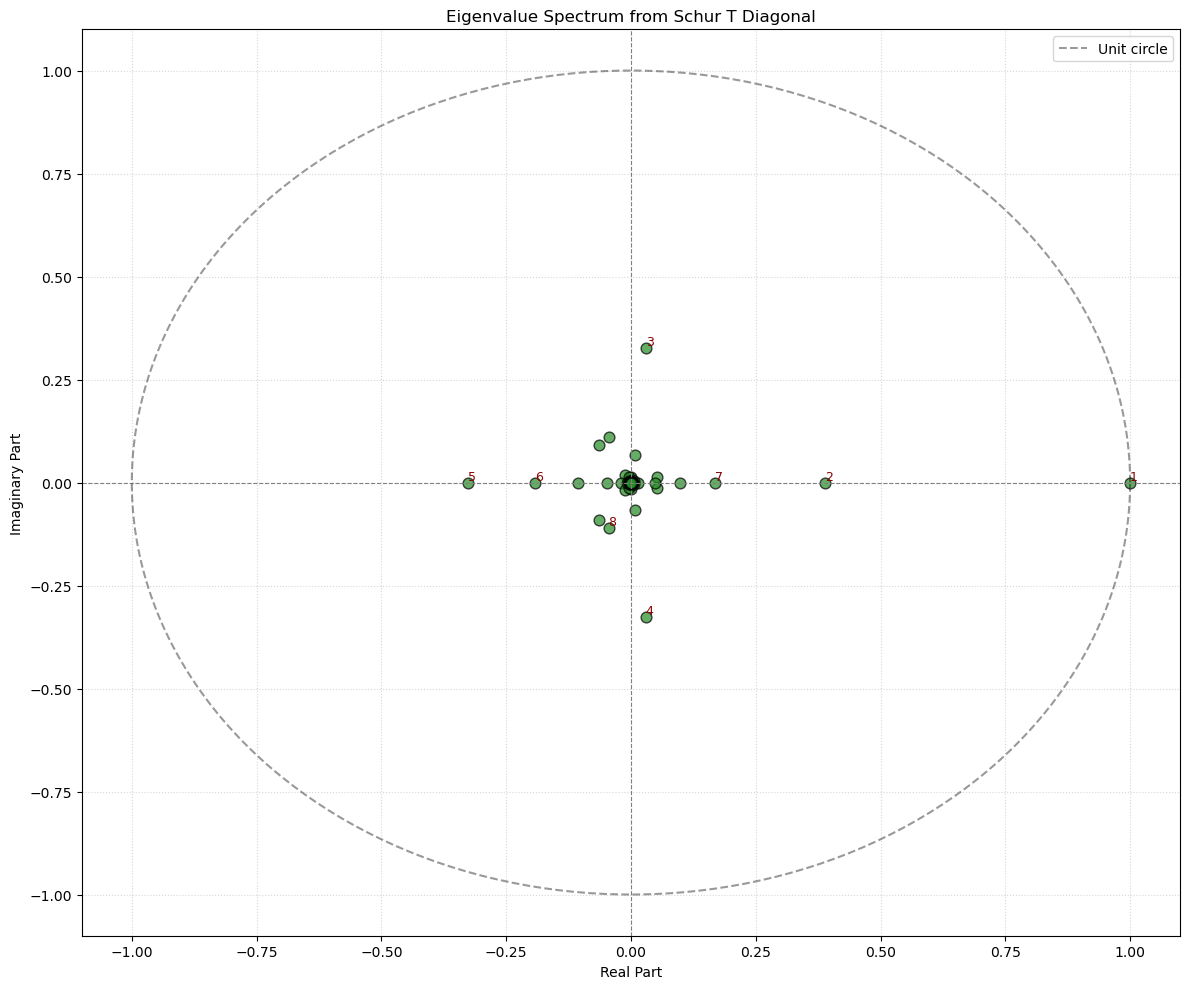

In [4]:
plot_eigenvalue_spectrum(eigenvalues, annotate_top=8)


## 5. Mode Listing: Upstream Drivers First

The listing below uses the standard upper-triangular Schur convention and prints modes in reverse Schur index order:

$$
n, n-1, \ldots, 1.
$$

For $y_{t+1}=Ty$:

- $T_{ij}$ means mode $j$ drives mode $i$.
- Incoming sources to mode $i$ are found across row $i$: `T_schur[i, j]`.
- Outgoing targets from mode $i$ are found down column $i$: `T_schur[k, i]`.
- In an upper-triangular $T$, higher-index modes drive lower-index modes.


In [5]:
unique_modes, schur_to_printed = print_upstream_schur_modes(
    analysis,
    cell_labels,
    coupling_tol=1e-5,
    top_n=5,
)


Identified 59 unique Schur modes.
Printed order: upstream drivers first; T[row receiver, column source].
Cascade Step 1 [Schur index 85; paired indexes [np.int64(85)]] | Type = Real | λ = -0.0000 | |λ| = 0.0000
Top incoming source(s): None
Top downstream target(s): Cascade Step 57 / Schur 3 (1.3323 - 0.1708i) | Cascade Step 59 / Schur 1 (-1.3258 + 0.0000i) | Cascade Step 54 / Schur 7 (-0.8454 + 0.0001i)
Principal cell types (Schur state vector):
  - EC LI II Pyramidal Fan                        | weight =  -0.8722 - 0.0000i | energy =  76.1% | phase = N/A
  - MEC LII III Pyramidal Multiform               | weight =   0.3091 + 0.0000i | energy =   9.6% | phase = N/A
  - MEC LIII Superficial Trilayered Interneuron   | weight =  -0.1553 - 0.0000i | energy =   2.4% | phase = N/A
  - EC LV Deep Pyramidal                          | weight =  -0.1333 - 0.0000i | energy =   1.8% | phase = N/A
  - MEC LV Pyramidal                              | weight =   0.1290 + 0.0000i | energy =   1.7% | ph

## 6. Dominant Eigenvalue and True Dominant Eigenvector

Use eigendecomposition when you specifically need eigenvectors.

Schur vectors are orthonormal and numerically stable, but `Q[:, i]` is a Schur vector, not generally an eigenvector. The block below therefore uses `eigvecs_ref` for the dominant eigenvector and uses `Q` only when discussing Schur coordinates.


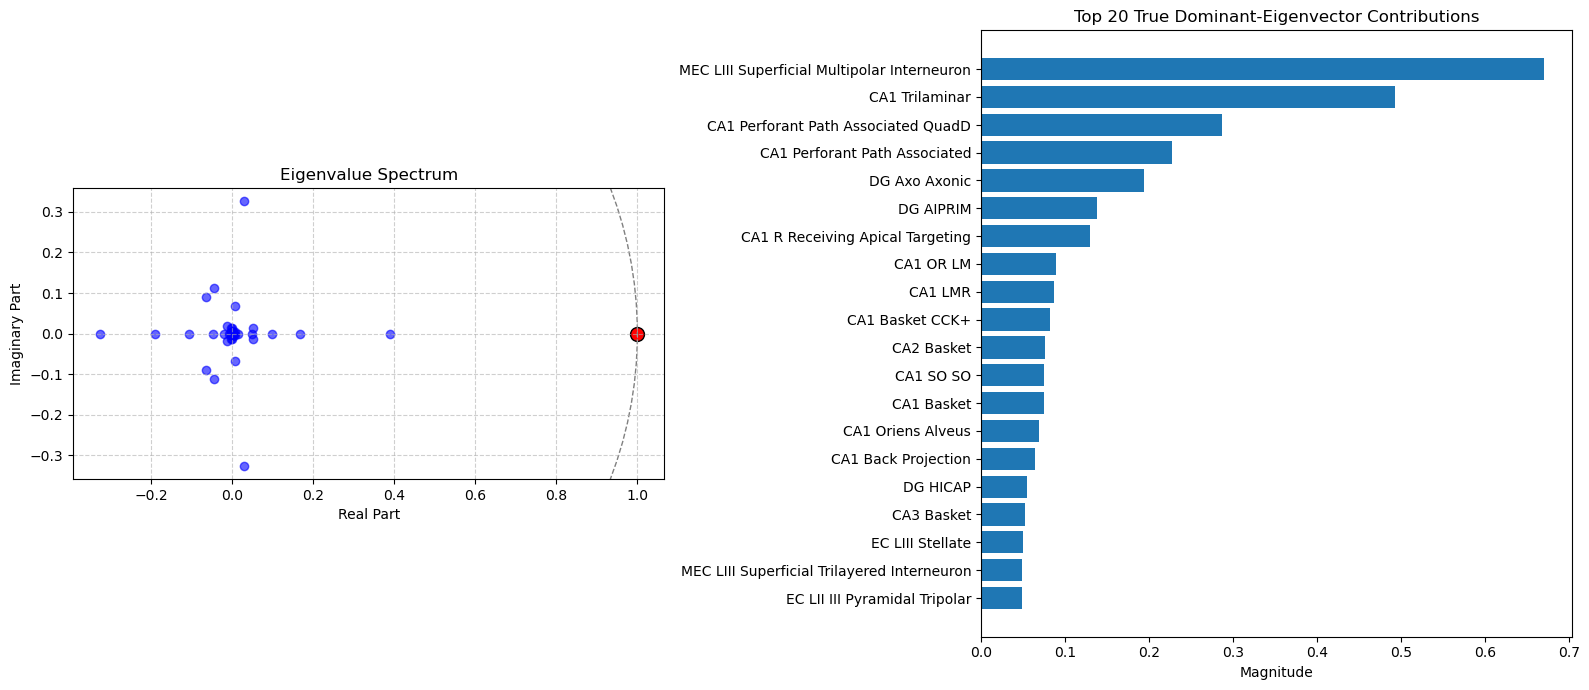

Dominant eigenvalue: 1.0000
Spectral radius ρ(M): 1.000000
Nearest Schur diagonal index: 1


In [6]:
dominant_mode = plot_true_dominant_eigenmode(analysis, cell_labels, top_n=20)


# Schur Decomposition: Upper-Triangular Coupling Map

The heatmap below visualizes the real part of $T$.

For the discrete-time model,

$$
y_{t+1}=Ty.
$$

The coupling convention is:

$$
T_{ij}: \text{ source mode } j \rightarrow \text{ receiver mode } i.
$$

Because $T$ is upper triangular, higher-index modes can feed lower-index modes. The notebook therefore prints cascade steps in reverse Schur-index order when you want upstream drivers first, while leaving $T$ itself in the standard upper-triangular form.


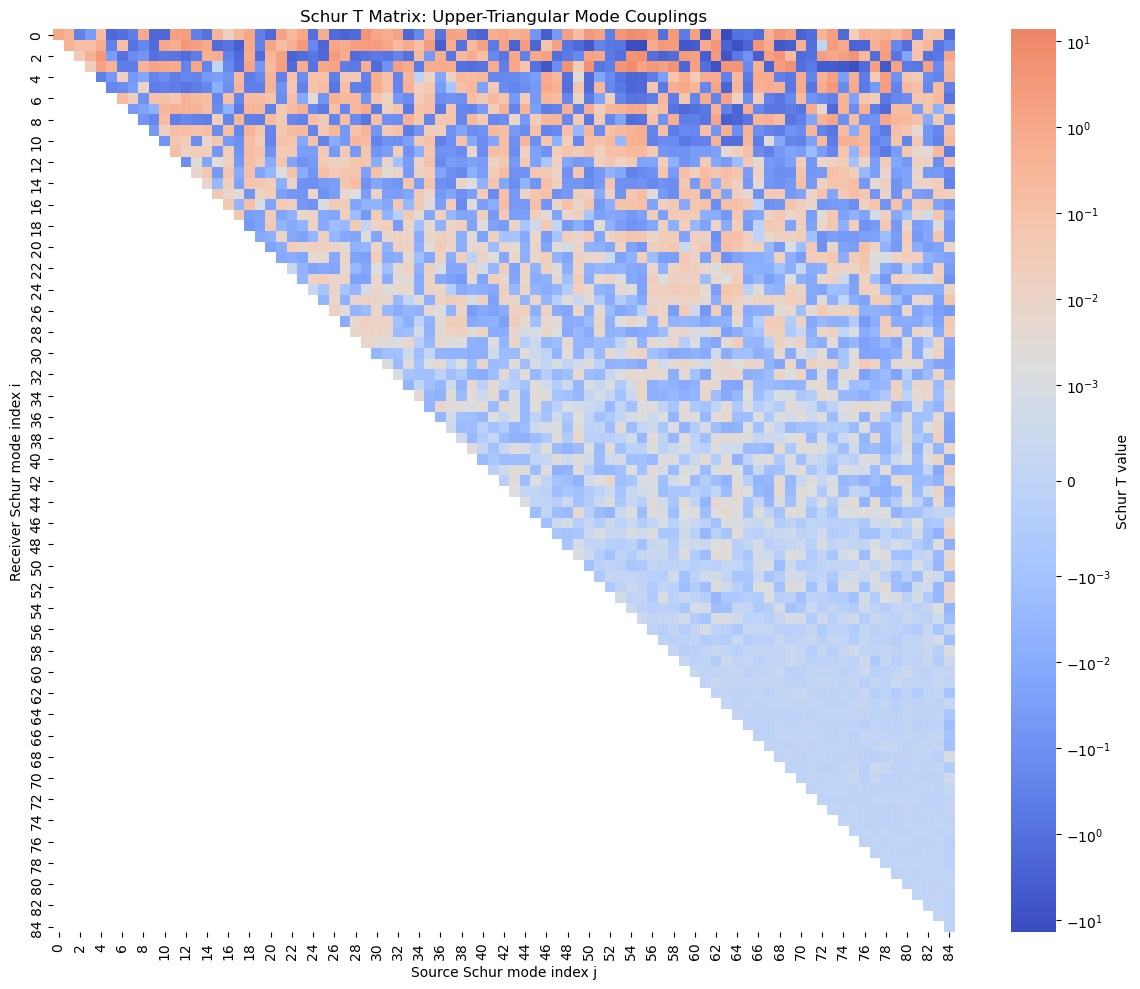

In [7]:
plot_schur_t_heatmap(T_schur)


## 7. First Printed Driver Mode

The first printed cascade step is the highest-index Schur mode, not `Q[:, 0]`.

This matches the upper-triangular convention where high-index modes can drive lower-index modes.


In [8]:
first_driver_schur_index = len(eigenvalues) - 1
station_df = pd.DataFrame({
    "Cell type": cell_labels,
    "Contribution": np.abs(Q[:, first_driver_schur_index]),
}).sort_values("Contribution", ascending=False)
print(station_df.head())


                                      Cell type  Contribution
62                       EC LI II Pyramidal Fan      0.872234
73              MEC LII III Pyramidal Multiform      0.309128
79  MEC LIII Superficial Trilayered Interneuron      0.155328
69                         EC LV Deep Pyramidal      0.133330
81                             MEC LV Pyramidal      0.128964


## 8. Manual Coupling Trace

To trace flow in Schur coordinates:

1. Pick a printed upstream driver mode.
2. Look at its **Top downstream target(s)**.
3. Continue from that target mode.
4. Use the **Top left-vector/action cell** column as the compact label for the cell type most associated with the action/readout of that mode.

Important distinction:

- The **Schur vector** column `Q[:, i]` describes the orthonormal state pattern for Schur mode `i`.
- The **left eigenvector** describes the projection/sensitivity/readout direction associated with the corresponding eigenvalue.
- In the cascade summary below, the old “Top Schur-vector cell” label is replaced by **Top left-vector/action cell** so the trace emphasizes who is most associated with the action/readout of each mode.

Do not interpret the first column of $T$ as outputs from Station 1. In $y_{t+1}=Ty$, column $j$ contains where source mode $j$ sends coupling, and row $i$ contains what drives receiver mode $i$.


In [9]:
mode_summary_df = upstream_mode_summary(analysis, cell_labels, coupling_tol=1e-5)
display(mode_summary_df.head(20))


,Cascade step,Schur index,Type,lambda,|lambda|,Top left-vector/action cell,Top Schur-state cell,Incoming count,Outgoing count
0,1,85,Real,-0.0000,1.569696e-06,EC LI II Pyramidal Fan,EC LI II Pyramidal Fan,0,84
1,2,84,Real,0.0000,8.939466e-06,EC LI II Pyramidal Fan,MEC LV Pyramidal,1,83
2,3,83,Real,0.0000,1.555430e-07,EC LI II Pyramidal Fan,CA3 Trilaminar,2,81
3,4,82,Real,0.0000,3.446822e-06,EC LI II Pyramidal Fan,CA1 Oriens Bistratified,2,78
4,5,81,Real,-0.0000 + 0.0000i,6.657770e-06,EC LI II Pyramidal Fan,CA1 Oriens Bistratified,3,79
5,6,80,Real,-0.0000 - 0.0000i,6.657770e-06,EC LI II Pyramidal Fan,CA1 Recurrent O LM,4,79
6,7,79,Real,0.0000,7.627783e-06,EC LI II Pyramidal Fan,CA1 O LMR,5,77
7,8,78,Complex Pair,-0.0000 + 0.0000i,1.770518e-05,EC LI II Pyramidal Fan,CA1 Radiatum Giant,7,77
8,9,76,Real,0.0000,1.797137e-05,EC LI II Pyramidal Fan,CA1 Radiatum Giant,7,75
9,10,75,Complex Pair,0.0000 - 0.0000i,2.397818e-05,EC LI II Pyramidal Fan,CA3 Horizontal Axo Axonic,10,73


# Investigating Self-Connections

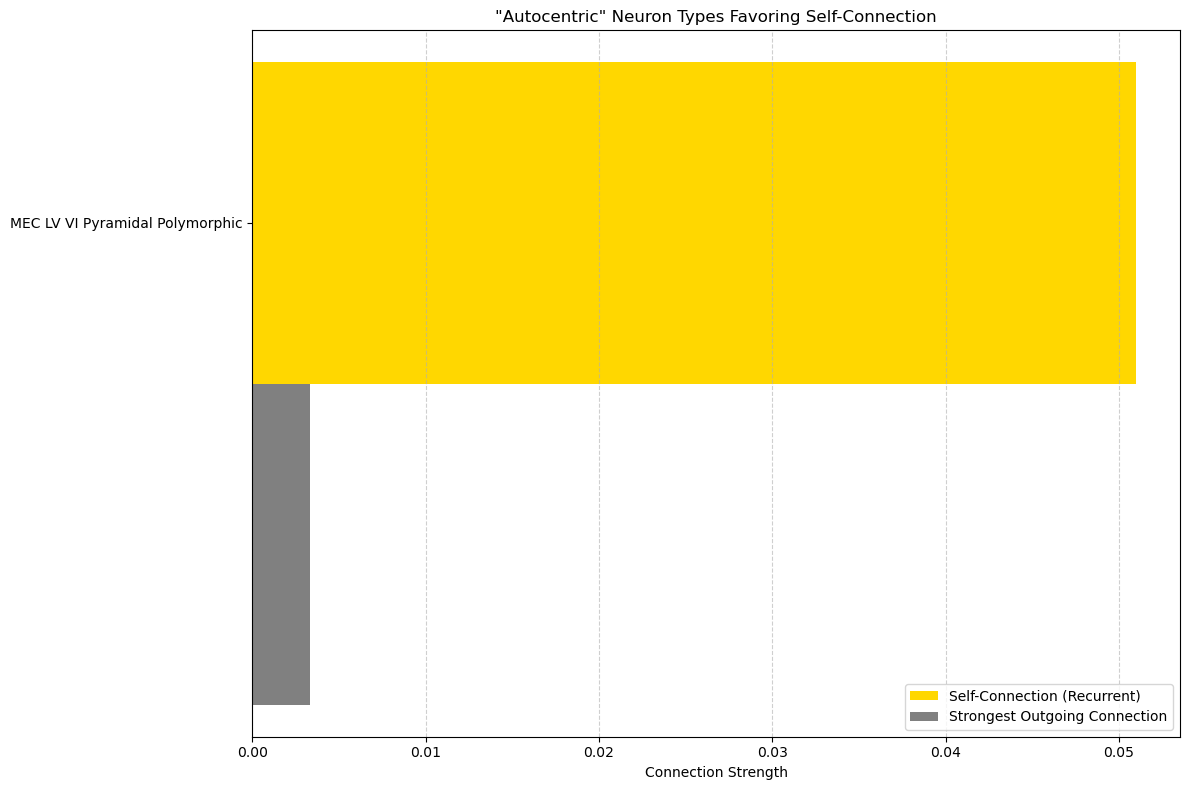

--- Autocentric Neuron Types ---
                            Neuron  Self-Connection  Max Outgoing
0  MEC LV VI Pyramidal Polymorphic         0.050969       0.00331


In [10]:
autocentric_df = find_autocentric_neurons(df_source_receiver)
plot_autocentric_neurons(autocentric_df)


Spectral radius ρ(M): 1.000000 (not stable)
Peak ||M^k||₂: 64.073739 at k=1
Discrete Kreiss-style grid proxy: 18.114862
Critical grid point: 1.2500 - 1.1990i


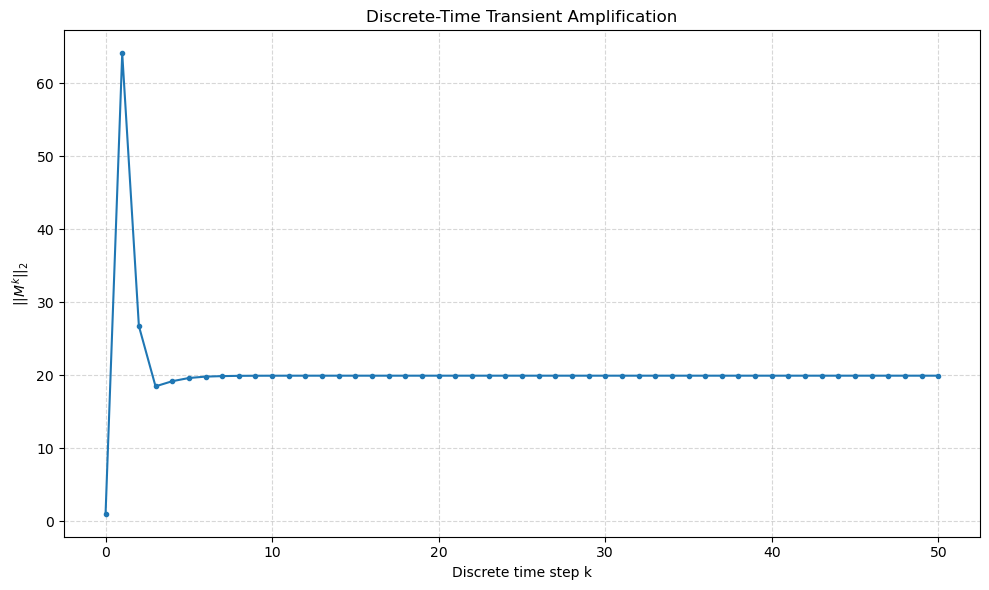

In [11]:
transient = analyze_discrete_transient_dynamics(M, k_max=50)
